In [1]:
# import Librairies
import pandas as pd 
import matplotlib.pyplot as plt

# Data & Clean
df = pd.read_csv(r'C:\Users\PC\Documents\Learning_PYTHON\data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


In [2]:
# We wil Learn how to use pivot tables and make chart according to the Trends we want 
# df.pivot_table (values ='TheColumnYouWanToCalculat' , index = 'ColumnToGroupBy_inRows' , columns = 'ColumnToGroupBy_inColumuns' , aggfunc = 'Calculate fonction')

df.pivot_table (
    values='salary_year_avg' ,
    index='job_country' ,
    columns='job_title_short' ,
    aggfunc='median' )

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,49950.00,NaN,69981.25,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.00,45000.0,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
Armenia,NaN,NaN,100500.00,48750.0,NaN,87021.0,NaN,NaN,NaN,NaN
Australia,70000.0,110000.0,109500.00,106712.5,139216.00,101029.0,50640.0,147500.0,157500.0,118350.0
...,...,...,...,...,...,...,...,...,...,...
Uruguay,NaN,NaN,100500.00,NaN,NaN,50000.0,NaN,NaN,57500.0,NaN
Uzbekistan,NaN,NaN,NaN,NaN,30750.00,NaN,NaN,NaN,NaN,NaN
Vietnam,79200.0,NaN,75550.00,96773.0,70000.00,57600.0,105837.5,147500.0,79200.0,53600.0


In [ ]:
# After we make the Pivot Table . we will create the Chart

# Find the 5 top countries by index
top_counties = df['job_country'].value_counts().sort_values(ascending=False).head(5).index

# Pivot Table
df_job_country_salary = df.pivot_table (
    values = 'salary_year_avg' ,
    index = 'job_country' ,
    columns = 'job_title_short' ,
    aggfunc = 'median' 
)

# Now let's filter the pivot table with just the top_countries using " .loc "
# Filter by rows (index)
df_job_country_salary = df_job_country_salary.loc [top_counties]

# Let's filter it more by job title to include only 3 jobs
# Filter by columns
job_title = ['Data Analyst' , 'Data Engineer' , 'Data Scientist']

df_job_country_salary = df_job_country_salary[job_title]

df_job_country_salary


job_title_short,Data Analyst,Data Engineer,Data Scientist
job_country,,,
United States,90000.0,125000.0,130000.0
India,100500.0,147500.0,114008.0
United Kingdom,87750.0,110000.0,105300.0
France,69175.0,98301.5,88128.0
Germany,103750.0,147500.0,131560.0


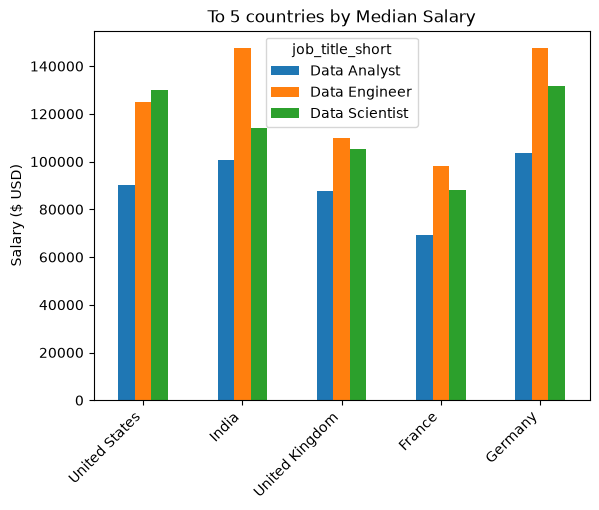

In [32]:
# Make the Chart
df_job_country_salary.plot (kind = 'bar')
plt.title("To 5 countries by Median Salary")
plt.xlabel("")
plt.xticks(rotation = 45 , ha='right')
plt.ylabel("Salary ($ USD)")
plt.show()